# Feature Extraction using AlexNet

In [10]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image


base_path = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Processed_Frames_Original1"
output_path = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Sequential_Features_Original_alexnet1"

os.makedirs(output_path, exist_ok=True)
--
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(" Using device:", device)


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.583973, 0.581955, 0.616053],
                         std=[0.249089, 0.258763, 0.236650])
])


alexnet = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)


alexnet = alexnet.features  # output shape → [256, 6, 6]

alexnet.eval().to(device)


def extract_features_sequence(video_folder):
    frame_features = []

    for frame_file in sorted(os.listdir(video_folder)):
        if not frame_file.endswith(".png"):
            continue

        frame_path = os.path.join(video_folder, frame_file)
        img = Image.open(frame_path).convert("RGB")
        img_tensor = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            feature_map = alexnet(img_tensor)          # [1, 256, 6, 6]
            feature = torch.flatten(feature_map, 1)    # [1, 9216]
            feature = feature.squeeze().cpu()          # [9216]
            frame_features.append(feature)

    if len(frame_features) == 0:
        return None

    # Stack all frame features → [num_frames, 9216]
    return torch.stack(frame_features)

for class_name in os.listdir(base_path):
    class_folder = os.path.join(base_path, class_name)
    if not os.path.isdir(class_folder):
        continue

    print(f"\n Processing Class: {class_name}")

    for video_folder in os.listdir(class_folder):
        video_path = os.path.join(class_folder, video_folder)
        if not os.path.isdir(video_path):
            continue

        print(f" Extracting sequential features from: {video_folder}")
        video_features = extract_features_sequence(video_path)

        if video_features is not None:
            save_path = os.path.join(output_path, f"{video_folder}.pt")
            torch.save({
                "features": video_features,  # shape: [num_frames, 9216]
                "class": class_name
            }, save_path)
            print(f" Saved sequential features → {save_path}")

print("\n Sequential feature extraction complete using AlexNet!")


 Using device: cpu

 Processing Class: Beautiful
 Extracting sequential features from: Beautiful_1
 Saved sequential features → C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Sequential_Features_Original_alexnet1\Beautiful_1.pt
 Extracting sequential features from: Beautiful_10
 Saved sequential features → C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Sequential_Features_Original_alexnet1\Beautiful_10.pt
 Extracting sequential features from: Beautiful_11
 Saved sequential features → C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Sequential_Features_Original_alexnet1\Beautiful_11.pt
 Extracting sequential features from: Beautiful_12
 Saved sequential features → C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Sequential_Features_Original_alexnet1\Beautiful_12.pt
 Extracting sequential features from: Beautiful_13
 Saved sequential features → C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Sequential_Features_Original_alexnet1\Beau

# Traning BiLSTM

 Using device: cpu
 Loaded 89 videos from 6 classes
Classes: ['Beautiful', 'Good_Morning', 'Happy', 'Headache', 'Hello', 'Namaste']
Epoch [1/80] - Loss: 2.0078 - Accuracy: 8.99%
Epoch [2/80] - Loss: 1.8507 - Accuracy: 12.36%
Epoch [3/80] - Loss: 1.7696 - Accuracy: 20.22%
Epoch [4/80] - Loss: 1.7558 - Accuracy: 26.97%
Epoch [5/80] - Loss: 1.7360 - Accuracy: 25.84%
Epoch [6/80] - Loss: 1.6974 - Accuracy: 29.21%
Epoch [7/80] - Loss: 1.7138 - Accuracy: 29.21%
Epoch [8/80] - Loss: 1.7294 - Accuracy: 29.21%
Epoch [9/80] - Loss: 1.6625 - Accuracy: 31.46%
Epoch [10/80] - Loss: 1.6711 - Accuracy: 30.34%
Epoch [11/80] - Loss: 1.6417 - Accuracy: 32.58%
Epoch [12/80] - Loss: 1.6568 - Accuracy: 38.20%
Epoch [13/80] - Loss: 1.6341 - Accuracy: 28.09%
Epoch [14/80] - Loss: 1.6272 - Accuracy: 39.33%
Epoch [15/80] - Loss: 1.6157 - Accuracy: 39.33%
Epoch [16/80] - Loss: 1.6068 - Accuracy: 42.70%
Epoch [17/80] - Loss: 1.5759 - Accuracy: 40.45%
Epoch [18/80] - Loss: 1.5881 - Accuracy: 42.70%
Epoch [19/80] 

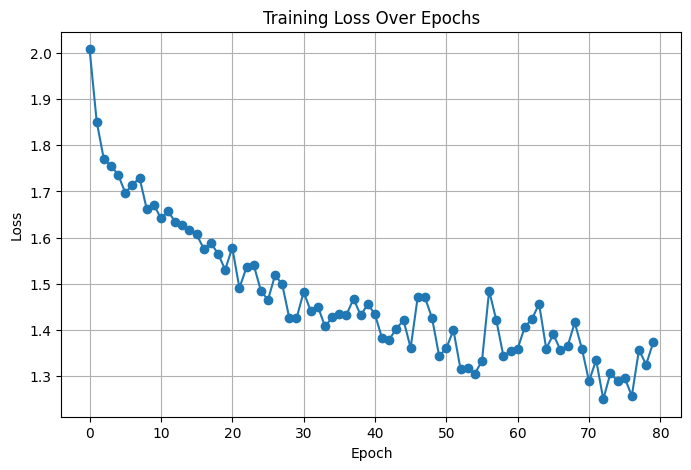

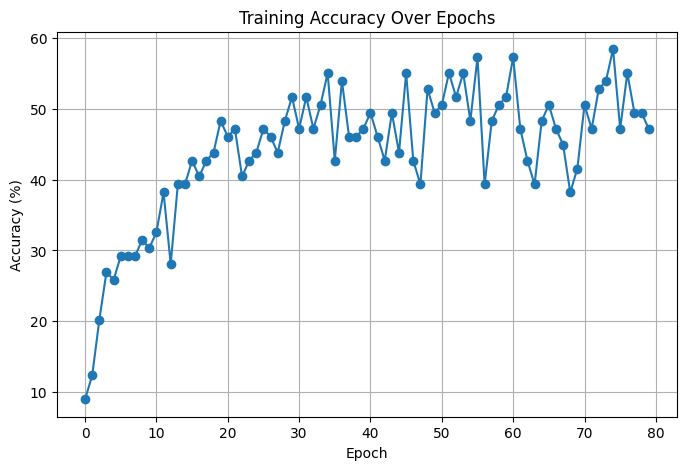

In [1]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt


features_path = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Sequential_Features_Original_alexnet1"
model_save_path = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\Models\sign_model_bilstm_sequence_original1_alexnet1.pth"


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(" Using device:", device)


class GestureSequenceDataset(Dataset):
    def __init__(self, feature_folder):
        self.samples = []
        for file in os.listdir(feature_folder):
            if file.endswith(".pt"):
                data = torch.load(os.path.join(feature_folder, file))
                self.samples.append((data["features"], data["class"]))

        self.class_names = sorted(list(set(c for _, c in self.samples)))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.class_names)}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        seq, cls_name = self.samples[idx]
        label = self.class_to_idx[cls_name]
        return seq, label


def collate_fn(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    padded = pad_sequence(sequences, batch_first=True)  # [B, max_len, 9216]
    return padded, torch.tensor(labels), lengths


dataset = GestureSequenceDataset(features_path)
loader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

print(f" Loaded {len(dataset)} videos from {len(dataset.class_names)} classes")
print("Classes:", dataset.class_names)


class BiLSTMModel(nn.Module):
    def __init__(self, input_dim=9216, hidden_dim=256, num_layers=1, num_classes=len(dataset.class_names)):
        super(BiLSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths):
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True)

        last_outputs = out[range(len(out)), lengths - 1, :]  # last time-step
        out = self.dropout(last_outputs)
        return self.fc(out)


model = BiLSTMModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)


loss_history = []
acc_history = []

EPOCHS = 80
for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for seqs, labels, lengths in loader:
        seqs, labels, lengths = seqs.to(device), labels.to(device), lengths.to(device)

        optimizer.zero_grad()
        outputs = model(seqs, lengths)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = total_loss / len(loader)
    epoch_acc = 100 * correct / total

    loss_history.append(epoch_loss)
    acc_history.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%")


torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": dataset.class_names
}, model_save_path)

print("\n Training complete!")
print(" Model saved at:", model_save_path)
print(" Classes:", dataset.class_names)



plt.figure(figsize=(8, 5))
plt.plot(loss_history, marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(acc_history, marker='o')
plt.title("Training Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()


# Prediction

In [1]:
import os
import cv2
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np

test_video_folder = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Test"
model_path = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\Models\sign_model_bilstm_sequence_original1_alexnet1.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(" Using device:", device)


checkpoint = torch.load(model_path, map_location=device)
class_names = checkpoint["class_names"]


class BiLSTMModel(nn.Module):
    def __init__(self, input_dim=9216, hidden_dim=256, num_layers=1, num_classes=len(class_names)):
        super(BiLSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
        
        last_outputs = out[range(len(out)), lengths - 1, :]
        out = self.dropout(last_outputs)
        return self.fc(out)


model = BiLSTMModel().to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(" Model Loaded Successfully\n")


alexnet = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
alexnet_features = alexnet.features  # outputs [B, 256, 6, 6]
alexnet_features.eval().to(device)


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.583973, 0.581955, 0.616053],
                         std=[0.249089, 0.258763, 0.236650])
])


def extract_video_features(video_path, frame_skip=1):
   
    cap = cv2.VideoCapture(video_path)
    frame_features = []
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
       
        if frame_idx % frame_skip != 0:
            frame_idx += 1
            continue
        frame_idx += 1

        # resize and convert
        frame = cv2.resize(frame, (224, 224))
        img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        img_tensor = transform(img).unsqueeze(0).to(device)  # [1,3,224,224]

        # Extract features using AlexNet features
        with torch.no_grad():
            fmap = alexnet_features(img_tensor)        # [1,256,6,6]
            feat = torch.flatten(fmap, 1).squeeze().cpu()  # [9216]
            frame_features.append(feat)

    cap.release()
    if len(frame_features) == 0:
        return None
    return torch.stack(frame_features)  # [seq_len, 9216]

def predict_video(video_path, frame_skip=1):
    features = extract_video_features(video_path, frame_skip=frame_skip)
    if features is None:
        return " No frames found", 0.0

    lengths = torch.tensor([len(features)], dtype=torch.long)
    features = features.unsqueeze(0).to(device) 
    with torch.no_grad():
        outputs = model(features, lengths)
        probs = torch.softmax(outputs, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item() * 100

    return class_names[pred_idx], confidence


print(" Starting predictions...\n")
for video_file in os.listdir(test_video_folder):
    if not video_file.endswith((".mp4", ".avi", ".mov")):
        continue

    video_path = os.path.join(test_video_folder, video_file)
    
    pred, conf = predict_video(video_path, frame_skip=1)
    print(f" {video_file} → Predicted: {pred} | Confidence: {conf:.2f}%")

print("\n All predictions complete!")


 Using device: cpu
 Model Loaded Successfully

 Starting predictions...

 Person10_Beautiful.mp4 → Predicted: Hello | Confidence: 22.57%
 Person10_Good_Morning.mp4 → Predicted: Headache | Confidence: 26.97%
 Person10_Headache.mp4 → Predicted: Hello | Confidence: 21.27%
 Person10_Hello.mp4 → Predicted: Headache | Confidence: 27.50%
 Person10_Namaste.mp4 → Predicted: Headache | Confidence: 37.03%
 Person1_Beautiful.mp4 → Predicted: Headache | Confidence: 23.59%
 Person1_Good_Morning.mp4 → Predicted: Happy | Confidence: 38.78%
 Person1_Happy.mp4 → Predicted: Happy | Confidence: 52.49%
 Person1_Headache.mp4 → Predicted: Happy | Confidence: 53.73%
 Person1_Hello.mp4 → Predicted: Happy | Confidence: 29.82%
 Person1_Namaste.mp4 → Predicted: Happy | Confidence: 49.64%
 Person2_Beautiful.mp4 → Predicted: Headache | Confidence: 24.58%
 Person2_Good_Morning.mp4 → Predicted: Headache | Confidence: 25.18%
 Person2_Happy.mp4 → Predicted: Happy | Confidence: 31.44%
 Person2_Headache.mp4 → Predicted: 